<a href="https://colab.research.google.com/github/medha-mannem/pothole-detection/blob/main/phd_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import MobileNet
from google.colab import drive
import tensorflow as tf
import cv2
import seaborn as sns
import os

In [ ]:
# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Define the ImageDataGenerator for training and testing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
# Path to your training and testing directories
train_dir = '/content/drive/MyDrive/pimages/train'
test_dir = '/content/drive/MyDrive/pimages/test'

In [ ]:
# Create training and testing sets
training_set = train_datagen.flow_from_directory(
    train_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary'
)

test_set = test_datagen.flow_from_directory(
    test_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary'
)

Found 2721 images belonging to 2 classes.
Found 294 images belonging to 2 classes.


In [ ]:
# Calculate steps_per_epoch and validation_steps
train_steps_per_epoch = training_set.samples // training_set.batch_size
val_steps = test_set.samples // test_set.batch_size

In [ ]:
# Define the distribution strategy
strategy = tf.distribute.MirroredStrategy()

with strategy.scope():
    # Define the model using MobileNet
    base_model = MobileNet(input_shape=(64, 64, 3), include_top=False, weights='imagenet')
    classifier = Sequential([
        base_model,
        Flatten(),
        Dense(units=128, activation='relu'),
        Dropout(0.5),
        Dense(units=1, activation='sigmoid')
    ])

    # Compile the model with additional metrics
    classifier.compile(optimizer='adam', loss='binary_crossentropy',
                       metrics=['accuracy',
                                tf.keras.metrics.Precision(name='precision'),
                                tf.keras.metrics.Recall(name='recall'),
                                tf.keras.metrics.AUC(name='auc')])

<ipython-input-7-9e29349ea05f>:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNet(input_shape=(64, 64, 3), include_top=False, weights='imagenet')


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Train the model
history = classifier.fit(
    training_set,
    steps_per_epoch=train_steps_per_epoch,
    epochs=100,
    validation_data=test_set,
    validation_steps=val_steps
)

Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


13/85 ━━━━━━━━━━━━━━━━━━━━ 13:05 11s/step - accuracy: 0.8194 - auc: 0.6778 - loss: 0.9611 - precision: 0.8847 - recall: 0.9041

/usr/local/lib/python3.10/dist-packages/PIL/Image.py:996: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


85/85 ━━━━━━━━━━━━━━━━━━━━ 771s 8s/step - accuracy: 0.8958 - auc: 0.8862 - loss: 0.4645 - precision: 0.9356 - recall: 0.9372 - val_accuracy: 0.7778 - val_auc: 0.9826 - val_loss: 0.6042 - val_precision: 1.0000 - val_recall: 0.5077
Epoch 2/100
 1/85 ━━━━━━━━━━━━━━━━━━━━ 1:00 715ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0265 - precision: 1.0000 - recall: 1.0000

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0265 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.8333 - val_auc: 1.0000 - val_loss: 0.5051 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.9705 - auc: 0.9944 - loss: 0.0771 - precision: 0.9811 - recall: 0.9819 - val_accuracy: 0.9028 - val_auc: 0.9722 - val_loss: 0.3924 - val_precision: 1.0000 - val_recall: 0.7846
Epoch 4/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0304 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0617 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 5/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.9747 - auc: 0.9875 - loss: 0.1059 - precision: 0.9797 - recall: 0.9887 - val_accuracy: 0.7917 - val_auc: 0.9856 - val_loss: 0.4105 - val_precision: 0.9855 - val_recall: 0.5354
Epoch 6/100
85/85 ━━━━━━━━━━━━━━━━━━━

In [ ]:
# Function to predict image and highlight potholes
def predict_and_draw(imgpath):
    try:
        # Load and preprocess the image
        predict_image = load_img(imgpath, target_size=(64, 64))
        predict_image_array = img_to_array(predict_image)
        predict_image_array = np.expand_dims(predict_image_array, axis=0) / 255.0

        # Predict the class
        result = classifier.predict(predict_image_array)

        # Convert image back to original size
        img = cv2.imread(imgpath)
        img = cv2.resize(img, (64, 64))

        # Draw bounding box if a pothole is detected
        if result[0][0] >= 0.5:
            print("Pothole detected!")
            # For simplicity, use a dummy bounding box
            x, y, w, h = 10, 10, 50, 50  # Replace with actual bounding box coordinates if available
            cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
            output_path = '/content/drive/MyDrive/predictions/' + os.path.basename(imgpath)
            cv2.imwrite(output_path, img)
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.title("Pothole detected")
        else:
            print("No Pothole detected.")
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
            plt.title("No Pothole detected")

        plt.show()
    except Exception as e:
        print(f"Error occurred: {e}")

In [ ]:

# Plot training & validation accuracy and loss values
plt.figure(figsize=(12, 8))

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

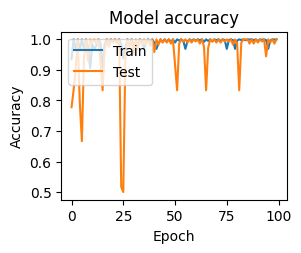

In [ ]:

# Accuracy
plt.subplot(2, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

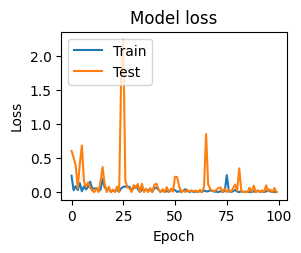

In [ ]:
# Loss
plt.subplot(2, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

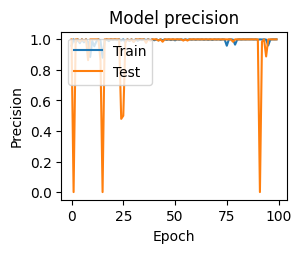

In [ ]:
# Precision
plt.subplot(2, 2, 3)
plt.plot(history.history['precision'])
plt.plot(history.history['val_precision'])
plt.title('Model precision')
plt.ylabel('Precision')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

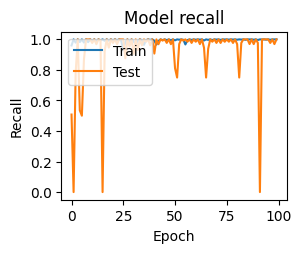

In [ ]:

# Recall
plt.subplot(2, 2, 4)
plt.plot(history.history['recall'])
plt.plot(history.history['val_recall'])
plt.title('Model recall')
plt.ylabel('Recall')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

In [ ]:

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 872ms/step


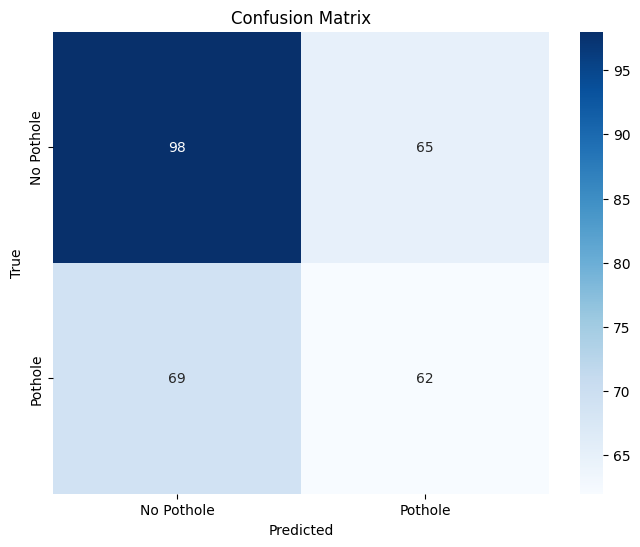

Classification Report
              precision    recall  f1-score   support

  No Pothole       0.59      0.60      0.59       163
     Pothole       0.49      0.47      0.48       131

    accuracy                           0.54       294
   macro avg       0.54      0.54      0.54       294
weighted avg       0.54      0.54      0.54       294



In [ ]:
# Generate confusion matrix
def plot_confusion_matrix():
    Y_pred = classifier.predict(test_set)
    y_pred = np.round(Y_pred).astype(int)
    y_true = test_set.classes

    cm = confusion_matrix(y_true, y_pred)
    cm_plot_labels = ['No Pothole', 'Pothole']
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cm_plot_labels, yticklabels=cm_plot_labels)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    # Print classification report
    print('Classification Report')
    target_names = ['No Pothole', 'Pothole']
    print(classification_report(y_true, y_pred, target_names=target_names))

plot_confusion_matrix()


In [ ]:

print(f"Final Training Accuracy: {history.history['accuracy'][-1]}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]}")
print(f"Final Training Loss: {history.history['loss'][-1]}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]}")

Final Training Accuracy: 1.0
Final Validation Accuracy: 1.0
Final Training Loss: 6.399643098120578e-06
Final Validation Loss: 3.1242461773217656e-06


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step
Pothole detected!


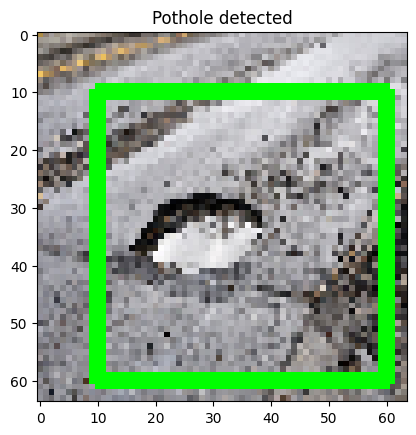

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
Pothole detected!


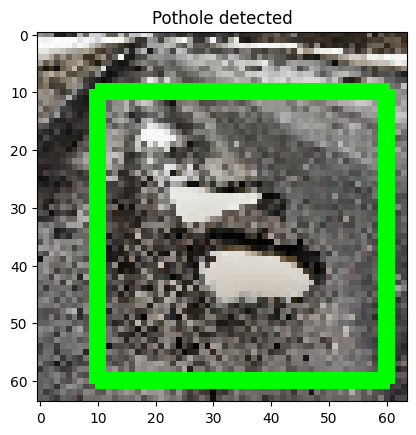

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
No Pothole detected.


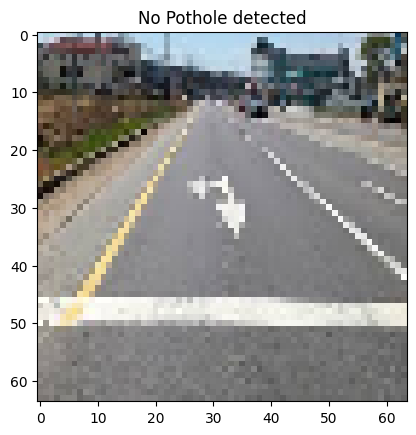

In [ ]:
# Predict example images
predict_and_draw('/content/drive/MyDrive/pimages/validation/test pothole 1.jpg')
predict_and_draw('/content/drive/MyDrive/pimages/validation/test pothole 2.jpg')
predict_and_draw('/content/drive/MyDrive/pimages/validation/test pothole 3.jpg')